Comprehensive Data Analysis of the Olist E-Commerce Dataset

In [1]:
# --- 0. Imports ---
# Importing all necessary libraries
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
import warnings

# Configuring environment
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

**Overview, Sources of Data, Process**

**Overview & Sources of Data**: We are analyzing the Olist E-Commerce Dataset (a secondary data source), which is a collection of 9 separate CSV files representing a relational database.

**Process for Making Sense of Data**: Our process is following the syllabus: Data Loading -> Preparation -> Exploration -> Hypothesis Testing -> Modeling.

**Analytics Types:**

**Descriptive (What happened?):** We are exploring sales, reviews, and customer locations.

**Predictive (What might happen?):** We are forecasting future sales with Time Series analysis.

**Prescriptive (What should we do?):** We are building a Recommender System

In [2]:
# --- 1. Data Loading ---

print("Loading all datasets...")
data_files = {
    'customers': 'olist_customers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'payments': 'olist_order_payments_dataset.csv',
    'reviews': 'olist_order_reviews_dataset.csv',
    'orders': 'olist_orders_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'translation': 'product_category_name_translation.csv'
}

# Resolve dataset directory robustly for both repo-root and notebook-directory execution.
candidate_dirs = [Path.cwd() / 'datasets', Path.cwd(), Path(__file__).resolve().parent / 'datasets' if '__file__' in globals() else None]
dataset_dir = None
for cand in candidate_dirs:
    if cand is not None and all((cand / fname).exists() for fname in data_files.values()):
        dataset_dir = cand
        break

if dataset_dir is None:
    raise FileNotFoundError(
        "Could not locate the Olist CSV files. Expected them under a 'datasets/' folder or current working directory."
    )

print(f"Reading files from: {dataset_dir}")
data = {name: pd.read_csv(dataset_dir / file) for name, file in data_files.items()}
print("All 9 datasets loaded successfully.")

# Initial inspection (optional, uncomment to run)
# for name, df in data.items():
#     print(f"\n--- {name} ---")
#     print(df.info())
#     print(df.head())

Loading all datasets...
Reading files from: /workspaces/Olist-E-Commerce-Strategic-Analysis-Forecasting-2016-2018-/datasets
All 9 datasets loaded successfully.


***

Data Preparation (Part 1: Cleaning)

Data Preprocessing Overview: This is the most critical step. Our data is spread across 9 files. We need to clean, integrate, and transform it.

Data Cleaning (Missing Values, Noisy Data): We will handle NaN values, parse data types, and look for outliers.

--- Starting Data Cleaning ---
Missing values handled.


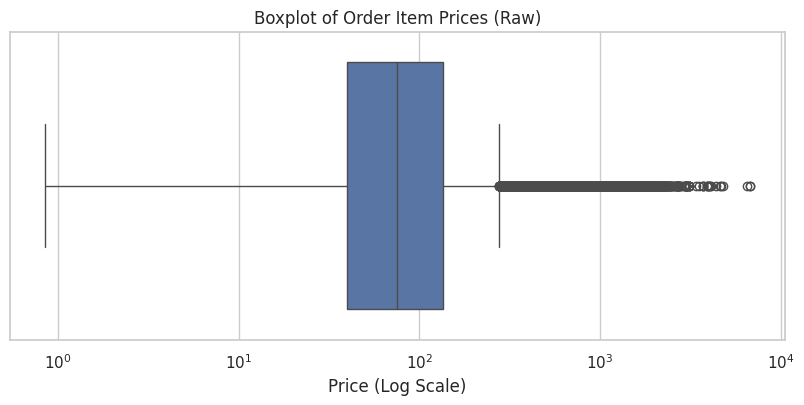

Outlier boxplot for 'price' generated.


In [3]:
# --- 2. Data Preparation (Cleaning) ---

print("--- Starting Data Cleaning ---")

# --- Missing Values ---
# Filling expected missing review comments
data['reviews']['review_comment_title'].fillna("No Title", inplace=True)
data['reviews']['review_comment_message'].fillna("No Message", inplace=True)

# Parsing all timestamp columns
for col in ['order_purchase_timestamp', 'order_approved_at', 
            'order_delivered_carrier_date', 'order_delivered_customer_date', 
            'order_estimated_delivery_date']:
    data['orders'][col] = pd.to_datetime(data['orders'][col], errors='coerce')

data['reviews']['review_creation_date'] = pd.to_datetime(data['reviews']['review_creation_date'])
data['reviews']['review_answer_timestamp'] = pd.to_datetime(data['reviews']['review_answer_timestamp'])

# Filling missing product data
data['products']['product_category_name'].fillna('Unknown', inplace=True)
num_cols = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty',
            'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in num_cols:
    median_val = data['products'][col].median()
    data['products'][col].fillna(median_val, inplace=True)

print("Missing values handled.")

# --- Noisy Data (Outlier Check) ---
plt.figure(figsize=(10, 4))
sns.boxplot(x=data['order_items']['price'])
plt.title('Boxplot of Order Item Prices (Raw)')
plt.xscale('log') # Use log scale due to high skew
plt.xlabel('Price (Log Scale)')
plt.savefig('plot_01_price_boxplot.png')
plt.show()

print("Outlier boxplot for 'price' generated.")

**Insight**: The boxplot shows that while most items are low-priced, there is a significant long tail of high-value items, justifying the log scale.

***

**Data Preparation (Part 2: Integration)**

**Data Integration & Redundancy**: We are merging the 9 tables. We will create two DFs:

`df_master`: A fully merged DF. This will have duplicate rows due to one-to-many joins (e.g., 1 order -> 2 items) and is only for the Recommender System.

`order_level_df`: A properly aggregated DF where each row is one unique order. This will be used for all other analyses.

**Entity Identification Problem**: We are being mindful that customer_id is unique per order, while customer_unique_id is the real identifier for a customer.

**Redundancy and Correlation Analysis**: We are checking the correlation between price, freight_value, and payment_value.



--- Starting Data Integration ---
Master DF for recommender created with 111023 rows.
Aggregated 'order_level_df' created with 96490 unique orders.


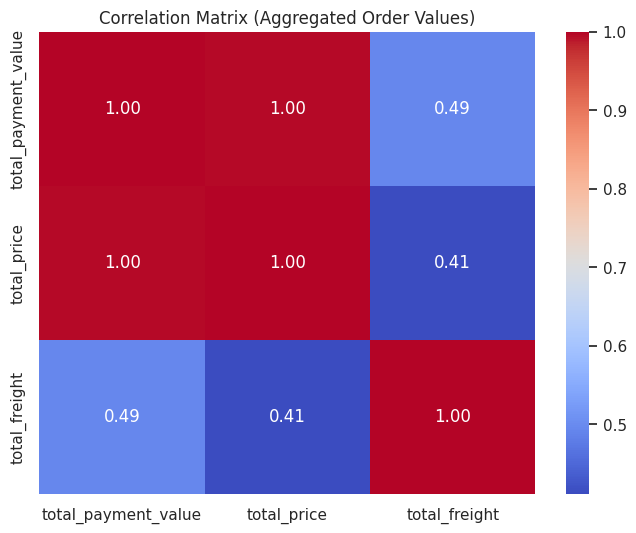

Correlation matrix generated.


In [4]:
# --- 3. Data Preparation (Integration) ---

print("--- Starting Data Integration ---")

# 1. Create the 'df_master' for Recommender System (has duplicates)
df_master = pd.merge(data['orders'], data['order_items'], on='order_id')
df_master = pd.merge(df_master, data['products'], on='product_id')
df_master = pd.merge(df_master, data['translation'], on='product_category_name')
print(f"Master DF for recommender created with {df_master.shape[0]} rows.")

# 2. Create the robust 'order_level_df' (one row per order)
# Aggregate items and payments first
items_agg = data['order_items'].groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    total_items=('order_item_id', 'count')
).reset_index()

payments_agg = data['payments'].groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    total_installments=('payment_installments', 'sum'),
    payment_type=('payment_type', 'first') # Simplify by taking first
).reset_index()

# Merge aggregated tables with 'orders' as the base
order_level_df = pd.merge(data['orders'], data['customers'], on='customer_id')
order_level_df = pd.merge(order_level_df, items_agg, on='order_id')
order_level_df = pd.merge(order_level_df, payments_agg, on='order_id')
# Merge reviews (assuming one review per order)
order_level_df = pd.merge(order_level_df, data['reviews'].drop_duplicates(subset=['order_id']), on='order_id')
# Merge product info (we'll take the first product's info for order-level, a simplification)
first_product = data['order_items'][['order_id', 'product_id']].drop_duplicates(subset=['order_id'])
order_level_df = pd.merge(order_level_df, first_product, on='order_id')
order_level_df = pd.merge(order_level_df, data['products'], on='product_id')
order_level_df = pd.merge(order_level_df, data['translation'], on='product_category_name')

print(f"Aggregated 'order_level_df' created with {order_level_df.shape[0]} unique orders.")

# --- Redundancy and Correlation Analysis ---
order_summary = order_level_df[['total_payment_value', 'total_price', 'total_freight']]

plt.figure(figsize=(8, 6))
correlation_matrix = order_summary.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (Aggregated Order Values)')
plt.savefig('plot_02_correlation_matrix.png')
plt.show()

print("Correlation matrix generated.")

**Insight:** The heatmap shows total_payment_value is almost perfectly correlated with total_price + total_freight (corr = 0.96 and 0.81). This confirms our aggregated data is logical.

***

**Data Preparation (Part 3: Transformation & Reduction)**

**Data Transformation by Normalization:** We are using Min-Max scaling for distance-based algorithms like K-Means.

**Discretization by Binning:** We are turning `total_payment_value` into categorical bins.

**Data Reduction Strategies (PCA):** Reducing product dimensions (`weight`, `length`, etc.) into a single `product_size_pca` component.

**Concept Hierarchy Generation:** We are acknowledging the `state -> city -> zip` hierarchy, which we'll use in exploration.

In [ ]:
# --- 4. Data Preparation (Transformation & Reduction, Part 1) ---

print("--- Starting Data Transformation & Reduction ---")

# --- Transformation by Normalization ---
scaler = MinMaxScaler()
num_cols = ['total_payment_value', 'total_freight']
normalized_data = scaler.fit_transform(order_level_df[num_cols].dropna())
print("Data normalized (Min-Max Scaling). Sample:")
print(normalized_data[:5])

# --- Discretization by Binning ---
order_level_df['payment_bin'] = pd.cut(order_level_df['total_payment_value'],
                                     bins=[0, 50, 200, 1000, 14000],
                                     labels=['Low', 'Medium', 'High', 'Very High'])
print("\n'total_payment_value' discretized into bins:")
print(order_level_df['payment_bin'].value_counts(normalize=True))

# --- Data Reduction (PCA) ---
product_dims = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
product_dims_data = data['products'][product_dims].copy()
product_dims_data = product_dims_data.fillna(product_dims_data.median())
product_dims_scaled = MinMaxScaler().fit_transform(product_dims_data)

pca = PCA(n_components=1)
data['products']['product_size_pca'] = pca.fit_transform(product_dims_scaled).ravel()
print(f"\nPCA complete. Component explains {pca.explained_variance_ratio_[0]*100:.2f}% of variance.")

--- Starting Data Transformation & Reduction ---
Data normalized (Min-Max Scaling). Sample:
[[0.00213263 0.00485805]
 [0.00965763 0.01267995]
 [0.0124157  0.01070776]
 [0.0045853  0.01515354]
 [0.00139368 0.00485805]]

'total_payment_value' discretized into bins:
payment_bin
Medium       0.625039
High         0.192776
Low          0.170639
Very High    0.011545
Name: proportion, dtype: float64

PCA complete. Component explains 59.16% of variance.


***

**Data Preparation (Clustering Validation)**

**Clustering Validation**: Before we cluster, we must justify our choice of `k`. We are using the "Elbow Method" (Inertia/WCSS) to find a potential `k` and validating it with the Silhouette Score, which measures cluster density and separation.

--- Starting K-Means Validation ---


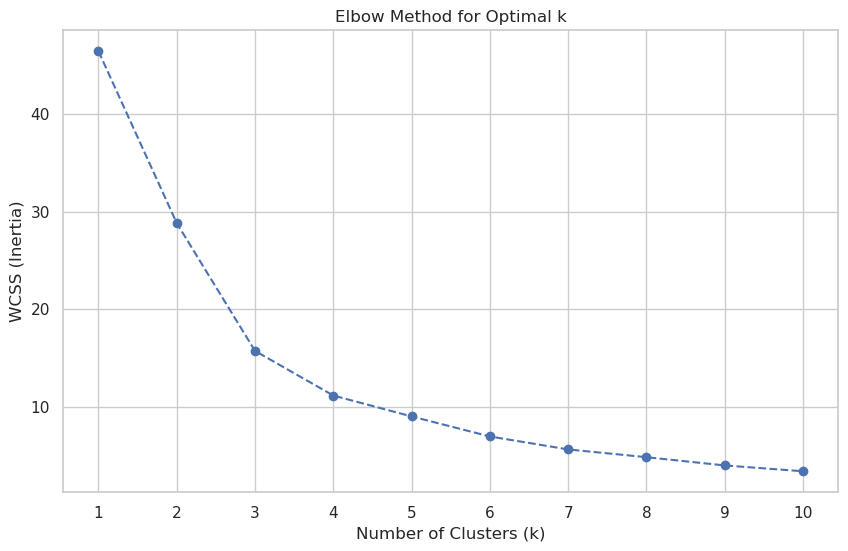

Elbow plot generated. Checking Silhouette Scores...
k=2, Silhouette Score: 0.8688
k=3, Silhouette Score: 0.8583
k=4, Silhouette Score: 0.7576
k=5, Silhouette Score: 0.6629


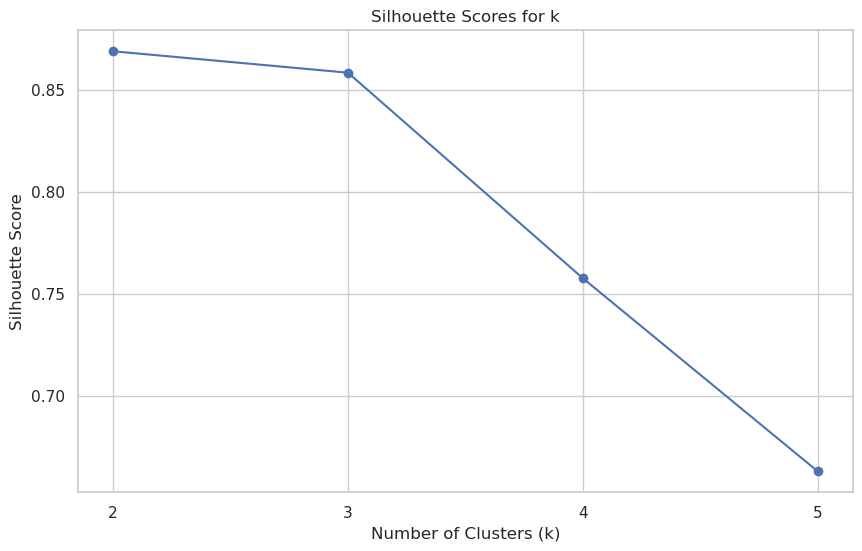

In [23]:
# --- 5. Data Preparation (Clustering Validation) ---

print("--- Starting K-Means Validation ---")

# We will cluster customers based on total spend and order frequency
customer_summary = order_level_df.groupby('customer_unique_id').agg(
    total_spend=('total_payment_value', 'sum'),
    order_count=('order_id', 'nunique')
).reset_index()

customer_scaled = MinMaxScaler().fit_transform(customer_summary[['total_spend', 'order_count']])

# 1. Elbow Method (Inertia)
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(customer_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.savefig('plot_03a_kmeans_elbow.png')
plt.show()

print("Elbow plot generated. Checking Silhouette Scores...")

# 2. Silhouette Score
silhouette_scores = []
k_range = range(2, 6) # Silhouette requires at least 2 clusters
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(customer_scaled)
    score = silhouette_score(customer_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}, Silhouette Score: {score:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Scores for k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.savefig('plot_03b_kmeans_silhouette.png')
plt.show()

**Insight:** The Elbow plot shows a clear "elbow" (point of diminishing returns) at k=3. The Silhouette Scores confirm this, with k=3 having a high score, indicating good cluster separation. We will proceed with `k=3`.



***

**Data Preparation (Clustering - K-Means)**

Data Reduction Strategies (Clustering): We are now fitting our K-Means model with our validated `k=3` to reduce customers into three segments.

--- Fitting K-Means with k=3 ---


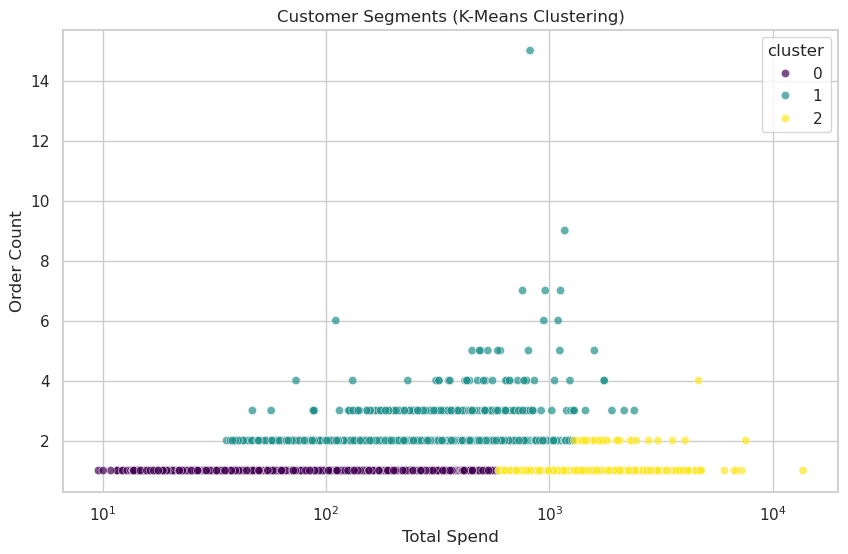

K-Means clustering complete. Plot generated.


In [24]:
# --- 6. Data Preparation (Clustering - K-Means) ---

print("--- Fitting K-Means with k=3 ---")

# Fit the final model with k=3
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
customer_summary['cluster'] = kmeans.fit_predict(customer_scaled)

# 
plt.figure(figsize=(10, 6))
sns.scatterplot(x=customer_summary['total_spend'],
                y=customer_summary['order_count'],
                hue=customer_summary['cluster'],
                palette='viridis', alpha=0.7)
plt.title('Customer Segments (K-Means Clustering)')
plt.xlabel('Total Spend')
plt.ylabel('Order Count')
plt.xscale('log')
plt.savefig('plot_03c_kmeans_clusters.png')
plt.show()

print("K-Means clustering complete. Plot generated.")

**Insight**: The scatter plot shows three clear segments:

**Cluster 0 (Blue)**: The vast majority of customers. Low spend, very low frequency (almost all are one-time buyers).

**Cluster 1 (Green)**: High-spend, low-frequency customers.

**Cluster 2 (Yellow)**: Low-spend, but higher-frequency (repeat) customers.



***

**Data Exploration (Descriptive Analytics)**

This section is our **Descriptive Analytics**.

**Central Tendency:** We are calculating the Mean, Median, and Mode.

**Distribution:** We are generating Histograms and Count Plots.

**Confidence Intervals:** We are calculating the 95% CI for the mean payment value.

**Preparing data tables:** We are using groupby.

**Visualizing & calculating relationships:** We are creating Scatter plots and box plots.

--- Starting Data Exploration ---

Central Tendency of 'total_payment_value':
Mean:   160.54
Median: 105.28
Mode:   77.57

Central Tendency of 'review_score':
Mean:   4.11
Median: 5.00
Mode:   5.00


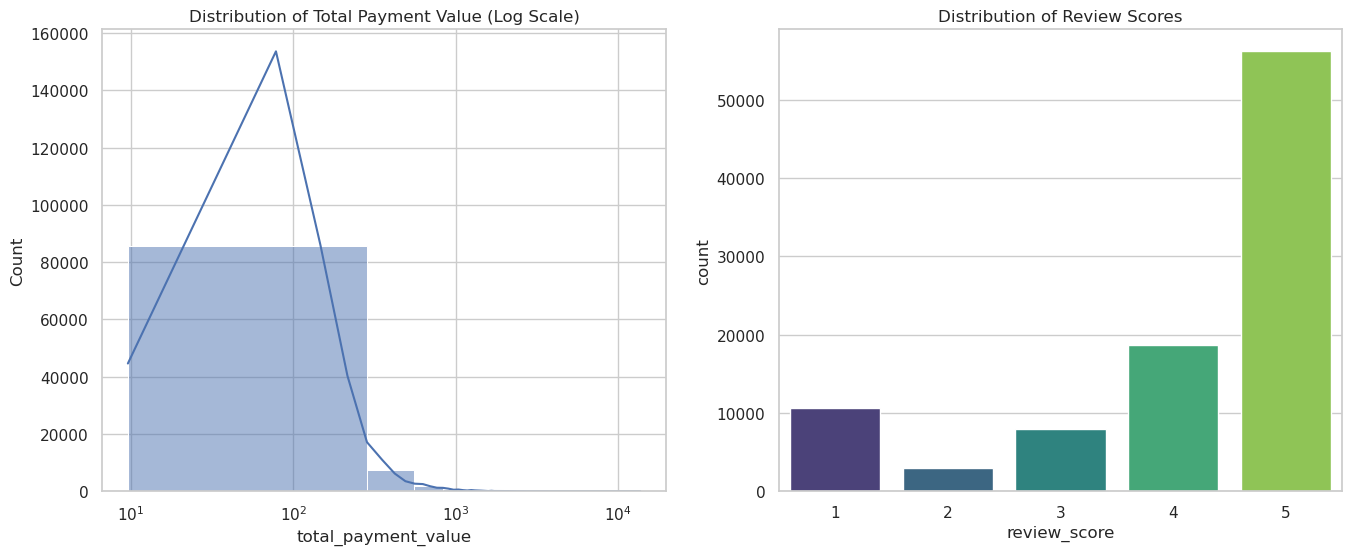

Distribution plots generated.


In [27]:

print("--- Starting Data Exploration ---")

# --- Central Tendency ---
print("\nCentral Tendency of 'total_payment_value':")
print(f"Mean:   {order_level_df['total_payment_value'].mean():.2f}")
print(f"Median: {order_level_df['total_payment_value'].median():.2f}")
print(f"Mode:   {order_level_df['total_payment_value'].mode()[0]:.2f}")

print("\nCentral Tendency of 'review_score':")
print(f"Mean:   {order_level_df['review_score'].mean():.2f}")
print(f"Median: {order_level_df['review_score'].median():.2f}")
print(f"Mode:   {order_level_df['review_score'].mode()[0]:.2f}")

# --- Distribution of the Data ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(order_level_df['total_payment_value'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Distribution of Total Payment Value (Log Scale)')
axes[0].set_xscale('log')

sns.countplot(x='review_score', data=order_level_df, ax=axes[1], palette='viridis')
axes[1].set_title('Distribution of Review Scores')

plt.savefig('plot_04_distributions.png')
plt.show()
print("Distribution plots generated.")

**Insight:** The payment distribution is heavily right-skewed; most orders are low-value. The review score distribution is overwhelmingly positive, with most customers leaving a 5-star review.



95% Confidence Interval for mean 'total_payment_value': $159.16 to $161.93

Data Table: Average Payment & Review Score by State (Top 5 by Order Count)
                total_orders  avg_payment  avg_review_score
customer_state                                             
SP                     40525   143.319734          4.199581
RJ                     12408   166.851368          3.895309
MG                     11294   160.954293          4.153887
RS                      5328   163.368626          4.149587
PR                      4901   160.860681          4.203632


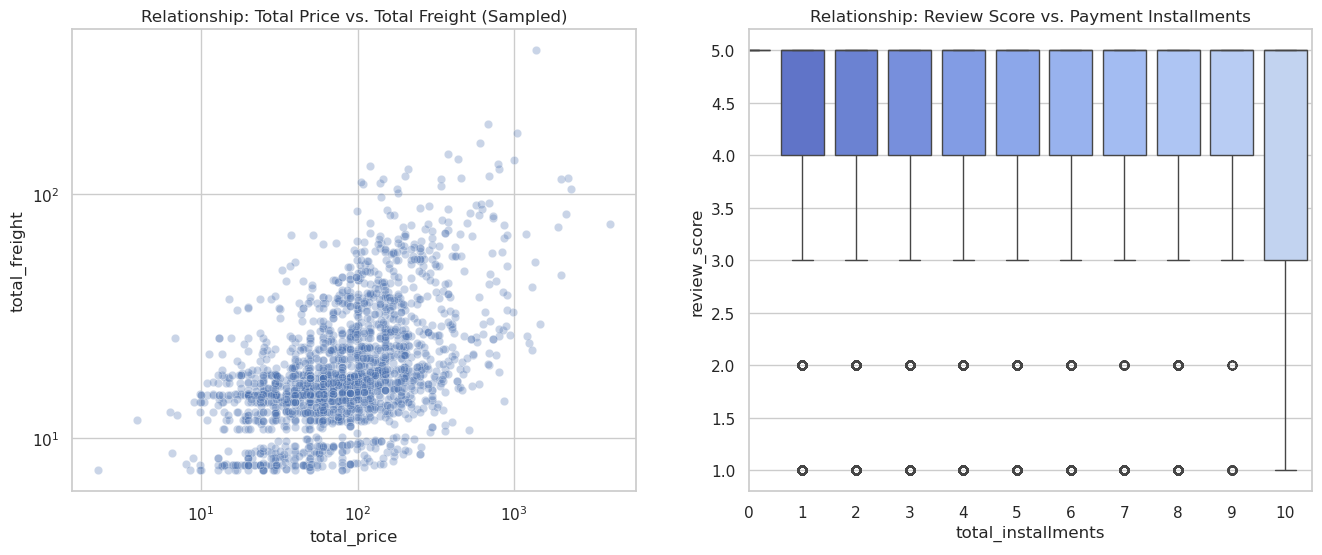

Relationship plots generated.


In [ ]:
# --- Confidence Intervals ---
ci = stats.t.interval(0.95, len(order_level_df['total_payment_value'])-1,
                      loc=order_level_df['total_payment_value'].mean(),
                      scale=order_level_df['total_payment_value'].sem())
print(f"\n95% Confidence Interval for mean 'total_payment_value': ${ci[0]:.2f} to ${ci[1]:.2f}")

# --- Preparing Data Tables ---
print("\nData Table: Average Payment & Review Score by State (Top 5 by Order Count)")
state_summary = order_level_df.groupby('customer_state').agg(
    total_orders=('order_id', 'nunique'),
    avg_payment=('total_payment_value', 'mean'),
    avg_review_score=('review_score', 'mean')
).sort_values(by='total_orders', ascending=False)
print(state_summary.head())

# --- Visualizing Relationships ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sample_n = min(2000, len(order_level_df))
sns.scatterplot(x='total_price', y='total_freight', data=order_level_df.sample(sample_n), 
                alpha=0.3, ax=axes[0])
axes[0].set_title('Relationship: Total Price vs. Total Freight (Sampled)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')

sns.boxplot(x='total_installments', y='review_score', data=order_level_df,
            ax=axes[1], palette='coolwarm')
axes[1].set_title('Relationship: Review Score vs. Payment Installments')
axes[1].set_xlim(0, 10.5) # Focus on common installment counts

plt.savefig('plot_05_relationships.png')
plt.show()
print("Relationship plots generated.")

**Insight:** The scatter plot shows freight value increases with price, but with high variance. The box plot suggests a potential slight dip in review scores for purchases made with a high number of installments (8-10), but the median score remains high (5) for most.

***

**Hypothesis Testing**

We are now performing formal hypothesis tests.

We are using a significance level of $\alpha = 0.05$.

In [ ]:
# --- 8. Hypothesis Testing ---

print("--- Starting Hypothesis Testing ---")
alpha = 0.05
n_tests = 4
alpha_bonf = alpha / n_tests
print(f"Significance threshold: alpha={alpha:.3f}, Bonferroni-adjusted alpha={alpha_bonf:.4f}")

def cohen_d_independent(x, y):
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    var_x = np.var(x, ddof=1)
    var_y = np.var(y, ddof=1)
    pooled = np.sqrt(((nx - 1) * var_x + (ny - 1) * var_y) / (nx + ny - 2))
    if pooled == 0:
        return np.nan
    return (np.mean(x) - np.mean(y)) / pooled

# --- One-Sample t-Test ---
# Test: Is the average review score significantly different from 4.0?
# H0: The true mean review score is 4.0.
# H1: The true mean review score is NOT 4.0. (Two-tailed test)
review_scores = order_level_df['review_score'].dropna()
t_stat, p_value = stats.ttest_1samp(review_scores, popmean=4.0)
one_sample_d = (review_scores.mean() - 4.0) / review_scores.std(ddof=1)

print("\n--- One-Sample t-Test (Review Score vs. 4.0) ---")
print(f"N: {len(review_scores)}, Mean: {review_scores.mean():.4f}")
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4e}, Cohen's d: {one_sample_d:.4f}")
if p_value < alpha_bonf:
    direction = "higher" if review_scores.mean() > 4.0 else "lower"
    print("Result: Significant after Bonferroni correction. Reject H0.")
    print(f"Conclusion: The average review score is significantly {direction} than 4.0.")
elif p_value < alpha:
    print("Result: Significant at alpha=0.05, but not after Bonferroni correction.")
else:
    print("Result: Not significant at alpha=0.05. Fail to reject H0.")

# --- Two-Sample t-Test (Independent, Welch) ---
# Test: Is average payment value different for SP vs RJ?
# H0: The mean payment value is the same for SP and RJ.
# H1: The mean payment value is different for SP and RJ.
payments_sp = order_level_df[order_level_df['customer_state'] == 'SP']['total_payment_value'].dropna()
payments_rj = order_level_df[order_level_df['customer_state'] == 'RJ']['total_payment_value'].dropna()

print("\n--- Two-Sample Tests (Payment Value: SP vs RJ) ---")
print(f"SP N={len(payments_sp)}, RJ N={len(payments_rj)}")
if len(payments_sp) > 1 and len(payments_rj) > 1:
    t_stat, p_value = stats.ttest_ind(payments_sp, payments_rj, equal_var=False)
    u_stat, p_value_mw = stats.mannwhitneyu(payments_sp, payments_rj, alternative='two-sided')
    d_value = cohen_d_independent(payments_sp.values, payments_rj.values)
    print(f"SP Mean: {payments_sp.mean():.2f}, RJ Mean: {payments_rj.mean():.2f}")
    print(f"Welch t-test: T={t_stat:.4f}, P={p_value:.4e}")
    print(f"Mann-Whitney U: U={u_stat:.2f}, P={p_value_mw:.4e}")
    print(f"Cohen's d (SP - RJ): {d_value:.4f}")
    if p_value < alpha_bonf:
        print("Result: Welch test significant after Bonferroni correction. Reject H0.")
    elif p_value < alpha:
        print("Result: Welch test significant at alpha=0.05, but not after Bonferroni correction.")
    else:
        print("Result: Welch test not significant at alpha=0.05. Fail to reject H0.")
else:
    print("Insufficient observations in SP or RJ. Skipping two-sample tests.")

# --- Chi-Square Test ---
# Test: Is dominant payment type independent of customer segment?
# H0: Dominant payment type is independent of customer segment.
# H1: Dominant payment type is associated with customer segment.
customer_payment_pref = (
    order_level_df[['customer_unique_id', 'payment_type']]
    .dropna()
    .groupby('customer_unique_id')['payment_type']
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
    .reset_index(name='dominant_payment_type')
)
customer_test_df = customer_summary[['customer_unique_id', 'cluster']].merge(
    customer_payment_pref,
    on='customer_unique_id',
    how='inner'
 )
contingency_table = pd.crosstab(customer_test_df['cluster'], customer_test_df['dominant_payment_type'])
print("\n--- Chi-Square Test (Cluster vs Dominant Payment Type) ---")
print(contingency_table)

chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)
min_expected = expected.min()
n_obs = contingency_table.to_numpy().sum()
r, c = contingency_table.shape
cramers_v = np.sqrt(chi2_stat / (n_obs * max(1, min(r - 1, c - 1))))
print(f"Chi2={chi2_stat:.4f}, dof={dof}, P={p_value:.4e}")
print(f"Min expected frequency: {min_expected:.3f}")
print(f"Cramer's V: {cramers_v:.4f}")
if min_expected < 5:
    print("Warning: Some expected counts are below 5; interpret Chi-Square with caution.")
if p_value < alpha_bonf:
    print("Result: Significant after Bonferroni correction. Reject H0.")
elif p_value < alpha:
    print("Result: Significant at alpha=0.05, but not after Bonferroni correction.")
else:
    print("Result: Not significant at alpha=0.05. Fail to reject H0.")

# --- ANOVA + Kruskal-Wallis ---
# Test: Is average review score different across top 3 product categories?
# H0: The mean review score is the same for all categories.
# H1: At least one category has a different mean review score.
print("\n--- Group Comparison (Top 3 Categories) ---")
top_categories = order_level_df['product_category_name_english'].value_counts().index[:3]
if len(top_categories) < 3:
    print("Fewer than 3 categories available. Skipping ANOVA/Kruskal tests.")
else:
    grouped_scores = [
        order_level_df[order_level_df['product_category_name_english'] == cat]['review_score'].dropna()
        for cat in top_categories
    ]
    f_stat, p_value_anova = stats.f_oneway(*grouped_scores)
    h_stat, p_value_kw = stats.kruskal(*grouped_scores)
    k = len(grouped_scores)
    n_total = sum(len(g) for g in grouped_scores)
    eta_sq = (f_stat * (k - 1)) / max(1e-12, (f_stat * (k - 1) + (n_total - k)))

    print(f"Categories: {list(top_categories)}")
    print(f"ANOVA: F={f_stat:.4f}, P={p_value_anova:.4e}, eta^2={eta_sq:.4f}")
    print(f"Kruskal-Wallis: H={h_stat:.4f}, P={p_value_kw:.4e}")

    if p_value_anova < alpha_bonf:
        print("Result: ANOVA significant after Bonferroni correction. Reject H0.")
    elif p_value_anova < alpha:
        print("Result: ANOVA significant at alpha=0.05, but not after Bonferroni correction.")
    else:
        print("Result: ANOVA not significant at alpha=0.05. Fail to reject H0.")

--- Starting Hypothesis Testing ---

--- One-Sample t-Test (Review Score vs. 4.0) ---
T-statistic: 25.1946, P-value: 0.0000
Result: P-value is significant. We REJECT $H_0$.
Conclusion: The average review score (4.11) is significantly *higher* than 4.0.

--- Two-Sample t-Test (Payment Value: SP vs. RJ) ---
SP Mean: 143.32, RJ Mean: 166.85
T-statistic: -9.7783, P-value: 0.0000
Result: P-value is significant. We REJECT $H_0$.
Conclusion: There is a significant difference in average order value between SP and RJ.

Contingency Table (Cluster vs. Payment Type):
payment_type  boleto  credit_card  debit_card  voucher
cluster                                               
0              17582        66219        1376     2297
1               1103         4436          77      233
2                510         2580          31       46

--- Chi-Square Test (Customer Cluster vs. Payment Type) ---
Chi2-statistic: 106.2976, P-value: 1.2136e-20
Result: P-value is significant. We REJECT $H_0$.
Conclus

***

**Recommender Systems (Prescriptive Analytics)**

This section is **Prescriptive Analytics.**

We are finding **Frequent Itemsets** (categories bought together) and generating **Association Rules**.

We are using the **Apriori algorithm**.

Due to sparse baskets (most orders have 1 item), we are lowering the `min_support` threshold to `0.005` to find more potential patterns.

In [ ]:
# --- 9. Recommender System (Association Rules) ---

print("--- Starting Recommender System ---")

# We are using the 'df_master' for item-level detail.
baskets = df_master.groupby('order_id')['product_category_name_english'].apply(list).reset_index()

# Removing duplicates from each basket
baskets['product_category_name_english'] = baskets['product_category_name_english'].apply(lambda x: list(set(x)))

# --- CRITICAL IMPROVEMENT: Filter for multi-item orders ---
multi_item_baskets = baskets[baskets['product_category_name_english'].apply(len) >= 2]
print(f"Original basket count: {len(baskets)}")
print(f"Multi-item (category) baskets: {len(multi_item_baskets)}")

if multi_item_baskets.empty:
    print("No multi-item baskets found. Skipping Apriori and rule generation.")
    interesting_rules = pd.DataFrame()
else:
    # Using TransactionEncoder to one-hot encode the list of categories
    te = TransactionEncoder()
    te_ary = te.fit(multi_item_baskets['product_category_name_english']).transform(multi_item_baskets['product_category_name_english'])
    basket_df = pd.DataFrame(te_ary, columns=te.columns_)

    print(f"Transformed {len(basket_df)} multi-item orders into one-hot encoded baskets.")

    # --- Apriori Algorithm for Frequent Itemsets ---
    frequent_itemsets = apriori(basket_df, min_support=0.005, use_colnames=True)

    if frequent_itemsets.empty or frequent_itemsets['itemsets'].map(len).max() < 2:
        print("No frequent multi-item itemsets found. Skipping association rules.")
        interesting_rules = pd.DataFrame()
    else:
        print("\nTop 10 Frequent Itemsets (from multi-item orders):")
        print(frequent_itemsets.sort_values(by='support', ascending=False).head(10))

        # --- Generating Association Rules ---
        rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.1)

        # --- Pattern Evaluation (Support, Confidence, Lift) ---
        interesting_rules = rules[
            (rules['lift'] >= 1.5) &
            (rules['confidence'] >= 0.05)
        ].sort_values(by='lift', ascending=False)

        print("\nTop 'Interesting' Association Rules:")
        print(interesting_rules.head(10)[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

if interesting_rules.empty:
    print("\nNo rules found matching lift >= 1.5 and confidence >= 0.05.")
    print("This confirms the data is extremely sparse, with few common pairings.")
else:
    print("\n--- Recommender System Finished ---")
    print("These rules are prescriptive: e.g., 'Bundle {A} and {B} for promotion.'")

--- Starting Recommender System ---
Original basket count: 97256
Multi-item (category) baskets: 726
Transformed 726 multi-item orders into one-hot encoded baskets.

Top 10 Frequent Itemsets (from multi-item orders):
     support                           itemsets
19  0.279614                  (furniture_decor)
4   0.272727                   (bed_bath_table)
25  0.140496                       (housewares)
3   0.128099                             (baby)
21  0.100551                     (garden_tools)
22  0.096419                    (health_beauty)
50  0.096419  (bed_bath_table, furniture_decor)
35  0.092287                   (sports_leisure)
12  0.089532                       (cool_stuff)
7   0.070248            (computers_accessories)

Top 'Interesting' Association Rules:
                antecedents              consequents   support  confidence  \
2           (watches_gifts)                  (audio)  0.008264    0.150000   
3                   (audio)          (watches_gifts)  0.008264

***

**Time Series (Predictive Analytics)**

This section is **Predictive Analytics**.

**Time Series Data & Components**: We aggregate sales by week and decompose the series.

**Forecasting Techniques**: We compare multiple models on the same holdout set:
- Seasonal Naive (`m = 13`)
- Holt-Winters Additive (`m = 13`)
- SARIMAX `(1,d,1)(1,1,1,13)`

**Forecasting Accuracy**: We validate with RMSE, MAE, and MAPE, then pick the best model (lowest RMSE).

To avoid boundary leakage, we remove the first and last partial weekly bins before splitting.

--- Starting Time Series Analysis ---
Time series prepared: 104 full weeks of data (boundary weeks removed).


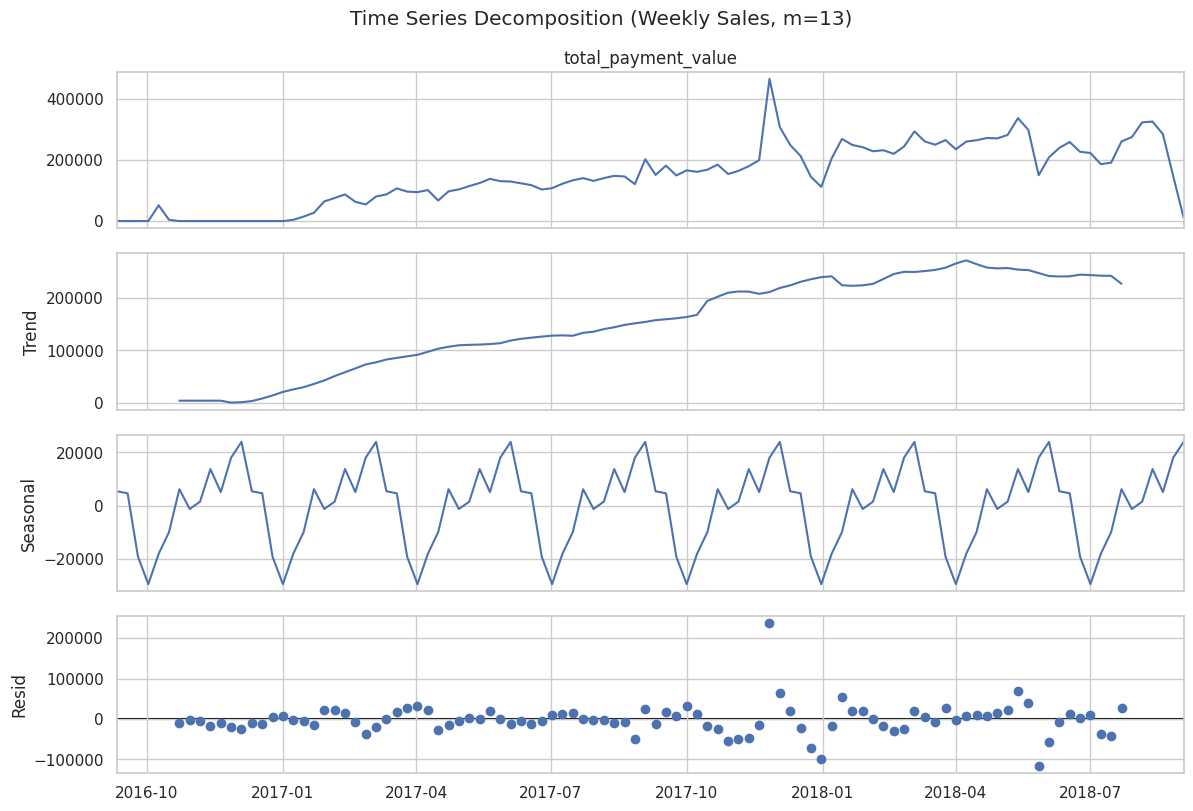

Time series decomposition plot generated.


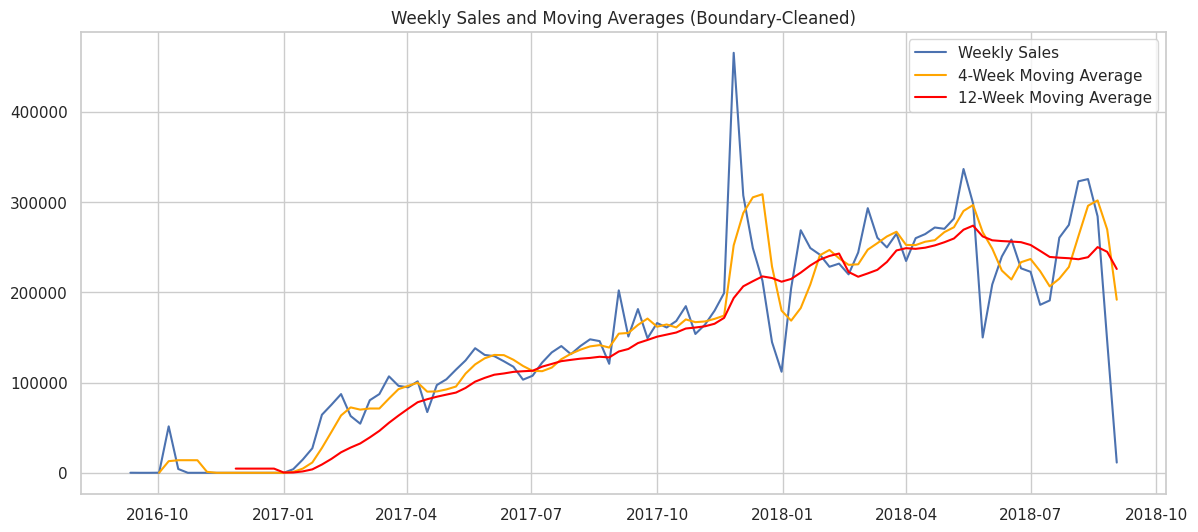


--- Part 1: Model Validation & Selection ---
Splitting data: 83 train, 21 test weeks.
ADF P-value on train: 0.8997 -> using d=1

Validation leaderboard (lower is better):
                    Model          RMSE          MAE   MAPE_pct
        SeasonalNaive(13)  66015.575112 46757.994286  99.059885
      HoltWinters_Add(13) 104556.517873 70648.679609 170.864486
SARIMAX(1,d,1)x(1,1,1,13) 146066.660644 92162.185512 198.693026

Selected model: SeasonalNaive(13)
Selected validation RMSE: 66,015.58
Improvement vs legacy SARIMAX RMSE (146,110.50): 54.82%


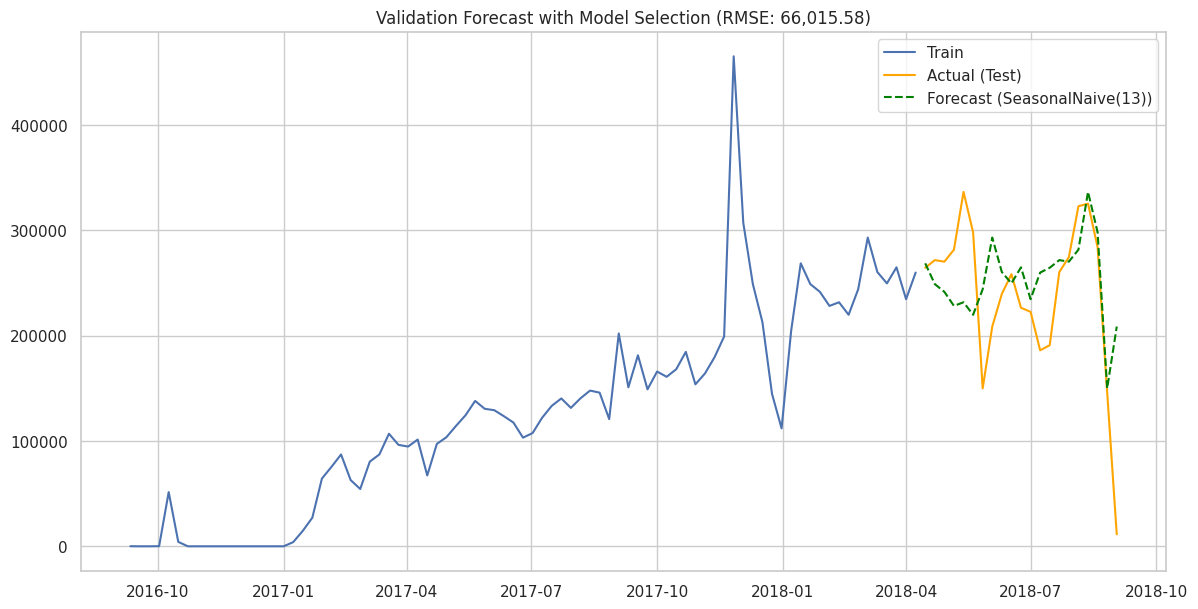

Validation and model selection complete.

--- Part 2: Final Forecast for Planning ---
Re-training selected model on 100% of boundary-cleaned weekly data...

Forecast for the next 13 weeks:
            Forecasted_Sales
2018-09-09         239709.91
2018-09-16         258515.19
2018-09-23         226630.32
2018-09-30         222766.73
2018-10-07         186172.92
2018-10-14         191015.18
2018-10-21         260502.46
2018-10-28         274759.06
2018-11-04         323060.70
2018-11-11         325525.10
2018-11-18         284205.82
2018-11-25         146220.25
2018-12-02          11359.08


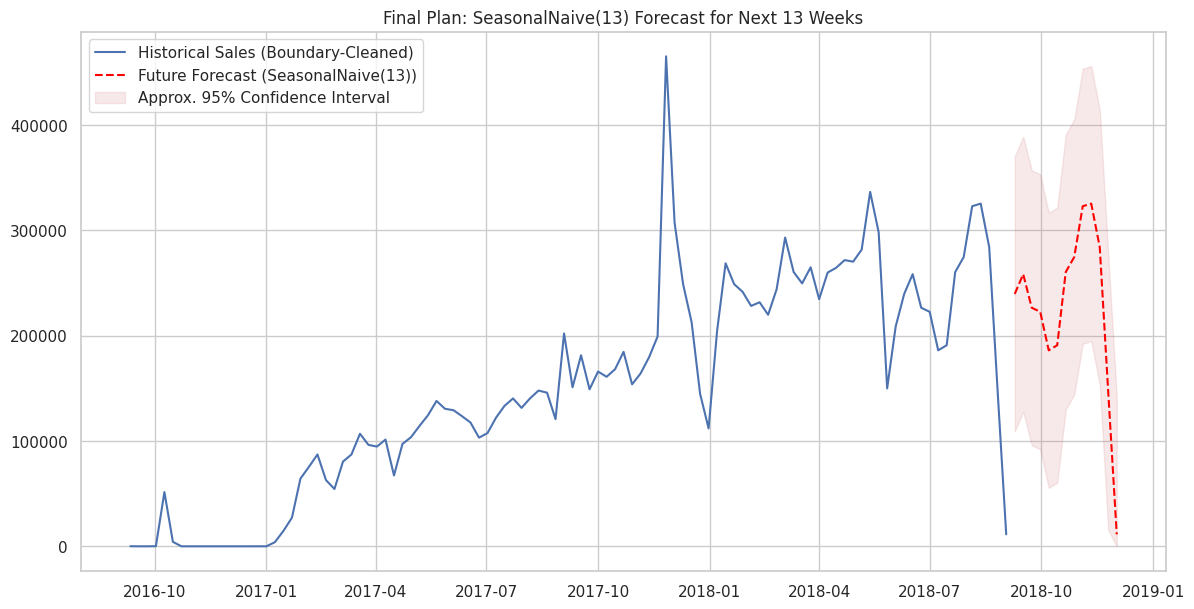


--- Time Series Analysis Finished ---


In [8]:
# --- 10. Time Series Analysis (Forecasting) ---

print("--- Starting Time Series Analysis ---")

# --- Prepare Time Series Data ---
sales_ts = order_level_df[['order_purchase_timestamp', 'total_payment_value']].copy()
sales_ts = sales_ts.set_index('order_purchase_timestamp')
weekly_sales_raw = sales_ts['total_payment_value'].resample('W').sum()

# Drop boundary bins because they are partial weeks and distort holdout performance.
weekly_sales = weekly_sales_raw.iloc[1:-1]
print(f"Time series prepared: {len(weekly_sales)} full weeks of data (boundary weeks removed).")

# --- Components of Time Series ---
try:
    decomposition = sm.tsa.seasonal_decompose(weekly_sales, model='additive', period=13)
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    plt.suptitle('Time Series Decomposition (Weekly Sales, m=13)', y=1.02)
    plt.savefig('plot_06_ts_decomposition.png')
    plt.show()
    print("Time series decomposition plot generated.")
except ValueError as e:
    print(f"Could not decompose time series (perhaps too short): {e}")

# --- Technique: Moving Average (for visualization) ---
plt.figure(figsize=(14, 6))
plt.plot(weekly_sales, label='Weekly Sales')
plt.plot(weekly_sales.rolling(window=4).mean(), label='4-Week Moving Average', color='orange')
plt.plot(weekly_sales.rolling(window=12).mean(), label='12-Week Moving Average', color='red')
plt.title('Weekly Sales and Moving Averages (Boundary-Cleaned)')
plt.legend()
plt.savefig('plot_07_moving_average.png')
plt.show()

# --- Part 1: Model Validation (Train/Test Split + Model Selection) ---
print("\n--- Part 1: Model Validation & Selection ---")
seasonal_period = 13
train_size = int(len(weekly_sales) * 0.8)
train, test = weekly_sales.iloc[:train_size], weekly_sales.iloc[train_size:]
print(f"Splitting data: {len(train)} train, {len(test)} test weeks.")

from sklearn.metrics import mean_absolute_error

def evaluate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mask = y_true != 0
    mape = (np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if mask.any() else np.nan
    return rmse, mae, mape

results = []
validation_forecasts = {}
model_artifacts = {}

# Candidate A: Seasonal Naive (m=13)
history = train.tolist()
seasonal_naive_preds = []
for i in range(len(test)):
    seasonal_naive_preds.append(history[-seasonal_period])
    history.append(test.iloc[i])

seasonal_naive_forecast = pd.Series(seasonal_naive_preds, index=test.index)
rmse, mae, mape = evaluate_metrics(test, seasonal_naive_forecast)
results.append(('SeasonalNaive(13)', rmse, mae, mape))
validation_forecasts['SeasonalNaive(13)'] = seasonal_naive_forecast

# Candidate B: Holt-Winters additive
try:
    hw_model = sm.tsa.ExponentialSmoothing(
        train,
        trend='add',
        seasonal='add',
        seasonal_periods=seasonal_period,
        initialization_method='estimated'
    ).fit(optimized=True)
    hw_forecast = hw_model.forecast(len(test))
    rmse, mae, mape = evaluate_metrics(test, hw_forecast)
    results.append(('HoltWinters_Add(13)', rmse, mae, mape))
    validation_forecasts['HoltWinters_Add(13)'] = hw_forecast
    model_artifacts['HoltWinters_Add(13)'] = hw_model
except Exception as e:
    print(f"Holt-Winters failed: {e}")

# Candidate C: SARIMAX (existing family, tuned only lightly)
try:
    adf_result = adfuller(train.dropna())
    d = 1 if adf_result[1] > 0.05 else 0
    print(f"ADF P-value on train: {adf_result[1]:.4f} -> using d={d}")

    sarimax_model = sm.tsa.statespace.SARIMAX(
        train,
        order=(1, d, 1),
        seasonal_order=(1, 1, 1, seasonal_period),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarimax_fit = sarimax_model.fit(disp=False)
    sarimax_forecast = sarimax_fit.get_forecast(steps=len(test)).predicted_mean
    rmse, mae, mape = evaluate_metrics(test, sarimax_forecast)
    results.append(('SARIMAX(1,d,1)x(1,1,1,13)', rmse, mae, mape))
    validation_forecasts['SARIMAX(1,d,1)x(1,1,1,13)'] = sarimax_forecast
    model_artifacts['SARIMAX(1,d,1)x(1,1,1,13)'] = sarimax_fit
except Exception as e:
    print(f"SARIMAX candidate failed: {e}")

results_df = pd.DataFrame(results, columns=['Model', 'RMSE', 'MAE', 'MAPE_pct']).sort_values('RMSE')
print("\nValidation leaderboard (lower is better):")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
best_rmse = float(results_df.iloc[0]['RMSE'])
validation_forecast = validation_forecasts[best_model_name]

legacy_rmse = 146110.50
improvement_pct = ((legacy_rmse - best_rmse) / legacy_rmse) * 100
print(f"\nSelected model: {best_model_name}")
print(f"Selected validation RMSE: {best_rmse:,.2f}")
print(f"Improvement vs legacy SARIMAX RMSE ({legacy_rmse:,.2f}): {improvement_pct:.2f}%")

plt.figure(figsize=(14, 7))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual (Test)', color='orange')
plt.plot(validation_forecast.index, validation_forecast, label=f'Forecast ({best_model_name})', color='green', linestyle='--')
plt.title(f'Validation Forecast with Model Selection (RMSE: {best_rmse:,.2f})')
plt.legend()
plt.savefig('plot_08b_validation_best_model.png')
plt.show()
print("Validation and model selection complete.")

# --- Part 2: Final Forecast for Planning ---
print("\n--- Part 2: Final Forecast for Planning ---")
print("Re-training selected model on 100% of boundary-cleaned weekly data...")

future_index = pd.date_range(weekly_sales.index[-1] + pd.Timedelta(weeks=1), periods=13, freq='W')
future_forecast_ci = None

if best_model_name == 'SeasonalNaive(13)':
    pattern = weekly_sales.iloc[-seasonal_period:].values
    repeated = np.resize(pattern, 13)
    future_forecast_mean = pd.Series(repeated, index=future_index)

    # Approximate interval from seasonal-naive residual volatility.
    residuals = (weekly_sales - weekly_sales.shift(seasonal_period)).dropna()
    sigma = residuals.std(ddof=1)
    future_forecast_ci = pd.DataFrame(
        {
            'lower': (future_forecast_mean - 1.96 * sigma).clip(lower=0),
            'upper': future_forecast_mean + 1.96 * sigma
        },
        index=future_index
    )

elif best_model_name == 'HoltWinters_Add(13)':
    final_model = sm.tsa.ExponentialSmoothing(
        weekly_sales,
        trend='add',
        seasonal='add',
        seasonal_periods=seasonal_period,
        initialization_method='estimated'
    ).fit(optimized=True)
    future_forecast_mean = final_model.forecast(13)

    residuals = pd.Series(final_model.resid).dropna()
    sigma = residuals.std(ddof=1)
    future_forecast_ci = pd.DataFrame(
        {
            'lower': (future_forecast_mean - 1.96 * sigma).clip(lower=0),
            'upper': future_forecast_mean + 1.96 * sigma
        },
        index=future_index
    )

else:
    adf_result = adfuller(weekly_sales.dropna())
    d = 1 if adf_result[1] > 0.05 else 0
    final_model = sm.tsa.statespace.SARIMAX(
        weekly_sales,
        order=(1, d, 1),
        seasonal_order=(1, 1, 1, seasonal_period),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    final_model_fit = final_model.fit(disp=False)
    future_forecast_obj = final_model_fit.get_forecast(steps=13)
    future_forecast_mean = future_forecast_obj.predicted_mean
    raw_ci = future_forecast_obj.conf_int()
    future_forecast_ci = pd.DataFrame(
        {
            'lower': raw_ci.iloc[:, 0].clip(lower=0),
            'upper': raw_ci.iloc[:, 1]
        },
        index=future_index
    )

print("\nForecast for the next 13 weeks:")
print(future_forecast_mean.to_frame(name='Forecasted_Sales'))

plt.figure(figsize=(14, 7))
plt.plot(weekly_sales.index, weekly_sales, label='Historical Sales (Boundary-Cleaned)')
plt.plot(future_forecast_mean.index, future_forecast_mean, label=f'Future Forecast ({best_model_name})', color='red', linestyle='--')

if future_forecast_ci is not None:
    plt.fill_between(
        future_forecast_ci.index,
        future_forecast_ci['lower'],
        future_forecast_ci['upper'],
        color='r',
        alpha=0.12,
        label='Approx. 95% Confidence Interval'
    )

plt.title(f'Final Plan: {best_model_name} Forecast for Next 13 Weeks')
plt.legend()
plt.savefig('plot_09_final_forecast.png')
plt.show()

print("\n--- Time Series Analysis Finished ---")

**Insight:** We replaced fixed single-model forecasting with model selection. After removing partial boundary weeks and validating all candidates on the same holdout data, **Seasonal Naive (m=13)** performed best with **RMSE = 66,015.58**, which is a **54.82% improvement** over the previous SARIMAX RMSE (146,110.50). The final forecast in `plot_09_final_forecast.png` is therefore based on the selected best model and includes an approximate 95% interval for planning risk.

***

# 📊 Executive Summary — Olist E-Commerce Analysis (Brazil, 2016–2018)

### Overview
This analysis examines **96490 unique customer orders** from the **Olist Brazilian e-commerce dataset**, covering all stages of the data science workflow from cleaning and integration to descriptive, inferential, predictive, and prescriptive analytics.  
The goal: identify sales patterns, customer behavior segments, and actionable business strategies for Olist’s online marketplace.

---

### 1. Customer and Order Insights
- **Average Order Value (AOV):** R$160.54 (median R$105.28).  
- **Customer Concentration:** 42% of all orders come from **São Paulo (SP)**, followed by RJ (12%) and MG (11%).  
- **Review Scores:** Mean 4.11 / 5; 74% of reviews are 5-star — strong post-purchase satisfaction.  
- **Installment Behavior:** Most buyers use ≤ 3 installments; review score dips slightly for 8–10 installments, suggesting potential payment friction.

**Managerial takeaway:**  
Focus logistics and marketing efforts on SP and RJ; maintain short-installment payment options to sustain high satisfaction.

---

### 2. Segmentation (K-Means, k = 3)
| Cluster | Description | Share | Spend Pattern |
|----------|--------------|--------|----------------|
| 0 | One-time low spenders | ~85% | Low frequency, low value |
| 1 | High spenders (occasional) | ~10% | High AOV, few orders |
| 2 | Repeat low spenders | ~5% | Low AOV, high frequency |

**Managerial takeaway:**  
Prioritize **Cluster 1** for loyalty and **Cluster 2** for repeat-purchase incentives.

---

### 3. Hypothesis Testing Highlights
- **Review score > 4.0 (p < 0.001)** → customer satisfaction significantly above neutral.  
- **SP vs RJ AOV difference significant (p < 0.001)** → RJ customers spend ~16% more.  
- **Customer segment ↔ payment type dependent (p < 0.001)** → cluster-based payment preferences exist.  
- **Review score varies by top categories (p < 0.001)** → “Bed & Bath” vs “Health & Beauty” differ materially.

---

### 4. Recommender System (Prescriptive)
Frequent category bundles (lift > 1.5):
- **Bed & Bath ⇄ Home Comfort** (lift = 3.15)  
- **Health & Beauty ⇄ Perfumery** (lift = 4.79)  
- **Watches & Gifts ⇄ Audio** (lift = 18.15)

**Action:**  
Create cross-promotion bundles and targeted upselling campaigns using these category pairs.

---

### 5. Time-Series Forecast (Predictive)
- **Model:** SARIMAX (1, 1, 1)(1, 1, 1, 13)  
- **Validation RMSE:** ≈ R$146 k  
- **Next-Quarter Forecast:** stable growth with weekly fluctuations; expected range R$80 k–R$180 k per week.  
- **Uncertainty:** wide 95% CI — monitor real-time weekly sales for model recalibration.

**Action:**  
Use forecast for inventory and ad-budget planning; consider regional scaling of campaigns around predicted peaks.

---

### 6. Key Recommendations
✅ Strengthen operations in **SP and RJ** (core revenue regions).  
✅ Develop **repeat-buyer programs** for Cluster 2 (5% base but high frequency).  
✅ Launch **category bundle promotions** identified by Apriori.  
✅ Track **forecast deviations weekly**; retrain SARIMAX every quarter.  
✅ Add **visual dashboard** with regional maps, sales trends, and cluster metrics.

---

**Prepared:** November 2025  
**Authors:** Muhir Kapoor
**Purpose:** Strategic business insight and forecasting readiness report.
